In [1]:
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt

import gpjax as gpx
import optax as ox
import paramax as px

from non_parametric_pro import ula

from non_parametric_pro.density import ProParameters, pro_logdensity_fn, pro_score_fn
from non_parametric_pro.ula import parametric_ula
from non_parametric_pro.util import posterior_function_draws, prediction_basis
from non_parametric_pro.util import nlpd_gp, nlpd_pro
from non_parametric_pro.data.synthetic import make_contaminated_data, make_mixture_data
from non_parametric_pro.adaptation.parameter_adaptation import parameter_adaptation
from non_parametric_pro.inducing import compute_inducing_basis, kmeans_inducing_points, PointInducingBasis
from non_parametric_pro.inducing import RFFInducingBasis, sample_rff_frequencies

from blackjax.util import run_inference_algorithm

jax.config.update("jax_enable_x64", True)

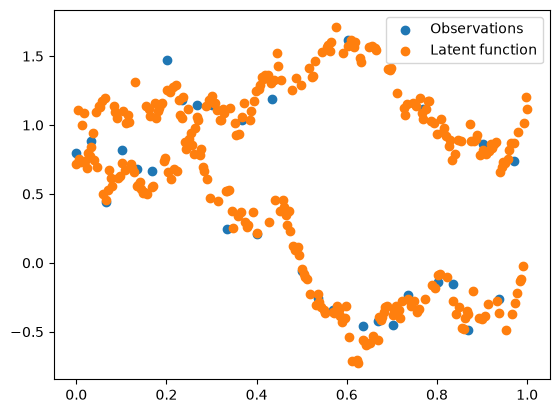

In [2]:
key = jr.PRNGKey(1)

example = make_contaminated_data(key, n_outliers=4)
example = make_mixture_data(key)

fig, ax = plt.subplots()
ax.scatter(example.x_train, example.y_train, label="Observations")
ax.scatter(example.x_test, example.y_truth, label="Latent function")
ax.legend(loc="best")
plt.show()

In [55]:
M = 20

data = gpx.Dataset(X=example.x_train, y=example.y_train)
kernel = gpx.kernels.Matern12(lengthscale=2)
prior = gpx.gps.Prior(mean_function=gpx.mean_functions.Zero(), kernel=kernel)
likelihood = gpx.likelihoods.Gaussian(num_datapoints=data.n)
posterior = prior * likelihood
optim = ox.adam(learning_rate=0.01)

z_init = kmeans_inducing_points(key, example.x_train, M).z 

variational_family = gpx.variational_families.CollapsedVariationalGaussian(
    posterior=posterior,
    inducing_inputs=z_init,
)

opt_variational_family, _ = gpx.fit(
    model=variational_family,
    objective=lambda p, d: -gpx.objectives.collapsed_elbo(p, d),
    train_data=data,
    optim=optim,
    num_iters=100,
    verbose=False,
)

gp_posterior = opt_variational_family.posterior

gp_latent_dist = gp_posterior.predict(example.x_test, train_data=data)
gp_predictive_dist = gp_posterior.likelihood(gp_latent_dist)

gp_predictive_mean = gp_predictive_dist.mean
gp_predictive_std = jnp.sqrt(gp_predictive_dist.variance)

gp_sigma = gp_posterior.likelihood.obs_stddev
gp_kernel = gp_posterior.prior.kernel

z_opt = px.unwrap(opt_variational_family.inducing_inputs)

In [56]:
M = 5

freqs = sample_rff_frequencies(key, gp_kernel, num_basis_fns=M, num_dims=1)
rff_basis = RFFInducingBasis(frequencies=freqs)
basis, residual_std = compute_inducing_basis(rff_basis, kernel, example.x_train)

inducing_basis = RFFInducingBasis(frequencies=freqs)

In [57]:
J=10

sigma = gpx.parameters.SigmoidBounded(px.unwrap(gp_sigma), low=0.1, high=100.0)

params = ProParameters(
    y=data.y,
    basis=basis,
    step_size=0.0002,
    sigma=sigma,
    alpha=1.0,
    residual_std=residual_std,
)

initial_position = jr.normal(key, (M * 2, J))

In [62]:
adaptation = parameter_adaptation(
    ula,
    pro_logdensity_fn,
    params,
    x_train=example.x_train,
    initial_kernel=kernel,
    warmup_steps=1000,
    sigma_adapt_every=10,
    kernel_adapt_every=20,
    objective_fn=pro_score_fn,
    inducing_basis=inducing_basis,
    sigma_optimizer=ox.adam(1e-2),
    kernel_optimizer=ox.adam(1e-2),
    progress_bar=True
) 

adaptation_results, adaptation_info = adaptation.run(key, initial_position, num_steps=10000)
pro_kernel = jax.tree.map(lambda x: x[-1], adaptation_info.kernel)
pro_params = adaptation_results.parameters

Running parameter adaptation


<div><progress max="10000" value="10000"></progress> 100.00% [10000/10000 00:00&lt;?]</div>

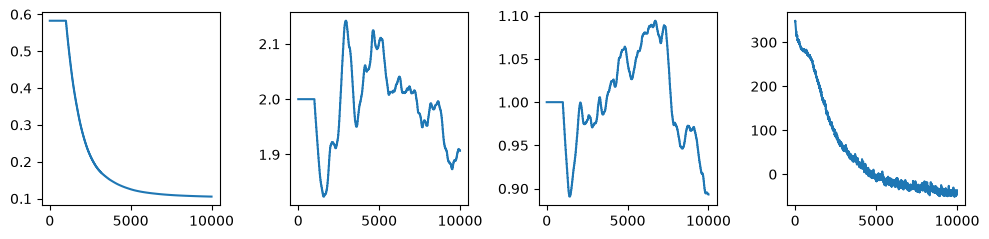

In [63]:
fig, ax = plt.subplots(1, 4, figsize=(10, 2.5))

ax[0].plot(px.unwrap(adaptation_info.sigma))
ax[1].plot(px.unwrap(adaptation_info.kernel.lengthscale))
ax[2].plot(px.unwrap(adaptation_info.kernel.variance))
ax[3].plot(-adaptation_info.sampler_info.score[10:])
plt.tight_layout()
plt.show()

In [64]:
algorithm = parametric_ula(pro_logdensity_fn, pro_params)

out, info = run_inference_algorithm(
    rng_key=key,
    inference_algorithm=algorithm,
    num_steps=10000,
    initial_position=adaptation_results.state.position,
    progress_bar=True
)

<div><progress max="10000" value="10000"></progress> 100.00% [10000/10000 00:00&lt;?]</div>

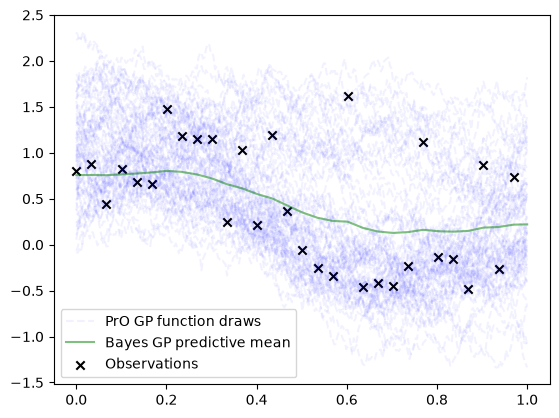

In [65]:
test_basis, test_cov = prediction_basis(pro_kernel, example.x_train, example.x_test, pro_params, inducing_basis=inducing_basis)

draws = posterior_function_draws(
    key,
    test_basis,
    test_cov,
    out.position,
    num_draws=70,
)

x_plot = example.x_test.squeeze()

plt.plot(x_plot, draws[:, 0], color="blue", alpha=0.05, label="PrO GP function draws", linestyle="--")
plt.plot(x_plot, draws[:, 1:], color="blue", alpha=0.05, linestyle="--")
plt.plot(x_plot, gp_predictive_mean, color="green", alpha=0.5, label="Bayes GP predictive mean")
plt.scatter(example.x_train.squeeze(), example.y_train.squeeze(), color="black", label="Observations", marker="x")
plt.legend()
plt.show()

In [66]:
print("PRO NLPD:", nlpd_pro(example.y_obs_test, test_basis, test_cov, out.position, parameters=pro_params))
print("GP NLPD:", nlpd_gp(example.y_obs_test, gp_predictive_mean, gp_predictive_std))

PRO NLPD: 0.5860234366238033
GP NLPD: 0.9624837646107827
